# Fish Species Clustering Project

This project aims to leverage machine learning algorithms to cluster fish species according to their physical attributes, specifically evaluating length, weight, and derived dimensional ratios.

<img src='https://www.niabizoo.com/wp-content/uploads/2018/09/ClownFish.jpg' width='750'>

In [1]:
#libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## EDA

In [3]:
df=pd.read_csv('fish_data.csv')

In [4]:
df.head()

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


In [5]:
df.sample(11)

,species,length,weight,w_l_ratio
1683,Otolithoides pama,21.49,3.90,0.18
113,Anabas testudineus,9.58,3.29,0.34
3591,Setipinna taty,17.74,3.28,0.18
2400,Polynemus paradiseus,10.90,4.20,0.39
1619,Otolithoides pama,20.08,3.97,0.20
3219,Setipinna taty,18.06,3.09,0.17
957,Otolithoides biauritus,19.56,3.32,0.17
44,Anabas testudineus,8.51,3.48,0.41
2943,Puntius lateristriga,14.15,2.69,0.19
2051,Pethia conchonius,10.41,4.60,0.44


In [6]:
df.tail()

,species,length,weight,w_l_ratio
4075,Sillaginopsis panijus,30.56,6.12,0.20
4076,Sillaginopsis panijus,29.66,6.11,0.21
4077,Sillaginopsis panijus,32.81,6.25,0.19
4078,Sillaginopsis panijus,29.78,6.11,0.21
4079,Sillaginopsis panijus,31.62,6.14,0.19


In [7]:
df.shape

(4080, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    4080 non-null   object 
 1   length     4080 non-null   float64
 2   weight     4080 non-null   float64
 3   w_l_ratio  4080 non-null   float64
dtypes: float64(3), object(1)
memory usage: 127.6+ KB


In [9]:
df.isnull().sum()

species      0
length       0
weight       0
w_l_ratio    0
dtype: int64

In [10]:
df.describe()

,length,weight,w_l_ratio
count,4080.000000,4080.000000,4080.000000
mean,17.353544,3.739875,0.252782
std,7.114684,1.040365,0.123046
min,6.360000,2.050000,0.080000
25%,11.327500,3.070000,0.170000
50%,17.350000,3.310000,0.190000
75%,22.585000,4.100000,0.340000
max,33.860000,6.290000,0.640000


In [11]:
df.corr(numeric_only=True)

,length,weight,w_l_ratio
length,1.000000,0.411584,-0.738174
weight,0.411584,1.000000,0.245835
w_l_ratio,-0.738174,0.245835,1.000000


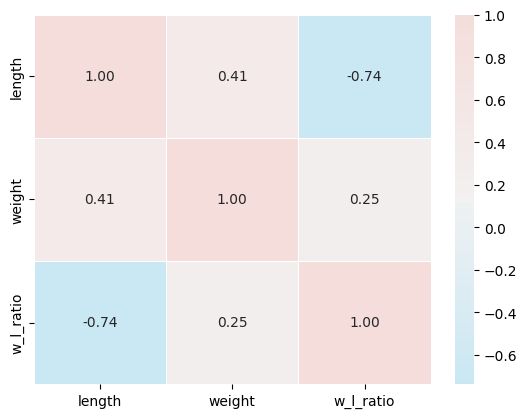

In [13]:
cmap = sns.diverging_palette(220, 20, as_cmap=True, s=60, l=90)
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=0.5, fmt=".2f", cmap=cmap);

In [14]:
df.columns

Index(['species', 'length', 'weight', 'w_l_ratio'], dtype='object')

In [15]:
df["species"].value_counts()

species
Setipinna taty            480
Anabas testudineus        476
Pethia conchonius         475
Otolithoides biauritus    468
Polynemus paradiseus      458
Sillaginopsis panijus     455
Otolithoides pama         435
Puntius lateristriga      418
Coilia dussumieri         415
Name: count, dtype: int64

<Axes: ylabel='count'>

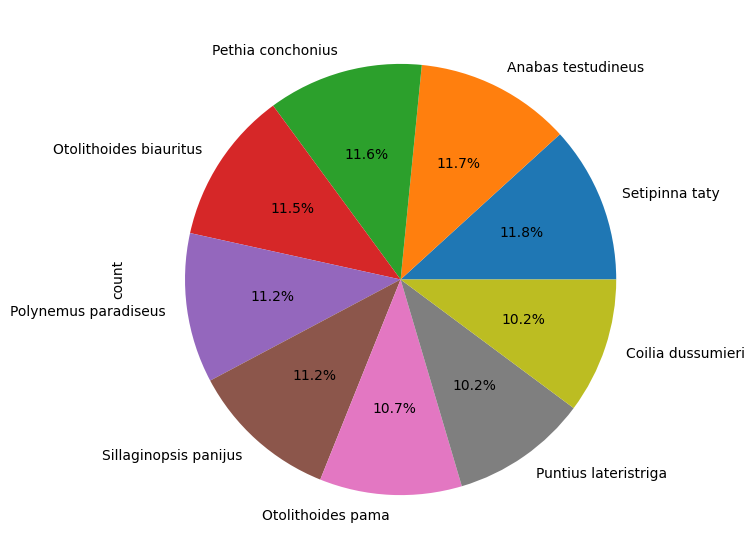

In [16]:
df["species"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))

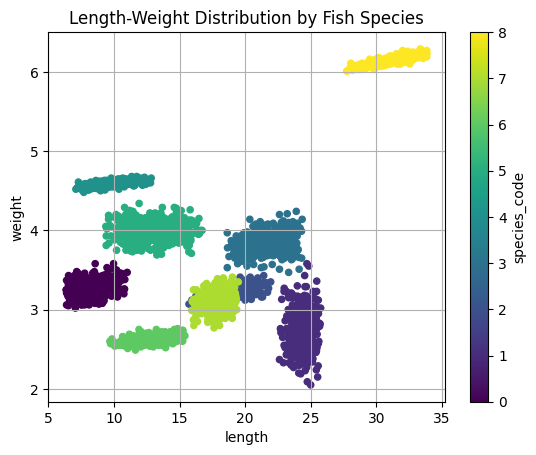

In [20]:
import matplotlib.pyplot as plt

# Categorize species column and create a numeric code column
df["species_code"] = df["species"].astype("category").cat.codes

df.plot.scatter(
    x="length",
    y="weight",
    c="species_code",
    colormap="viridis",
    title="Length-Weight Distribution by Fish Species",
    grid=True,
)

plt.show()

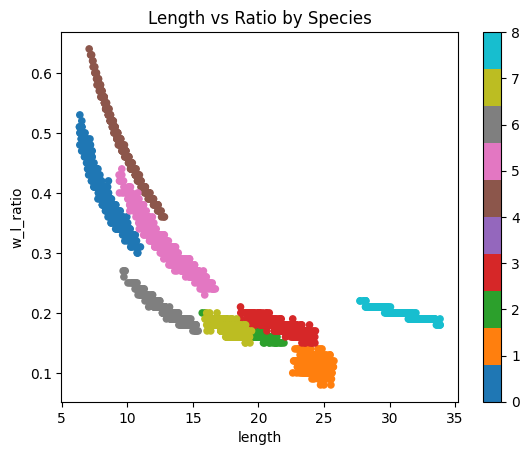

In [23]:
# Length vs. Ratio
df.plot.scatter(
    x="length",
    y="w_l_ratio",
    c=df["species"].astype("category").cat.codes,
    colormap="tab10",
    title="Length vs Ratio by Species",
)
plt.show()

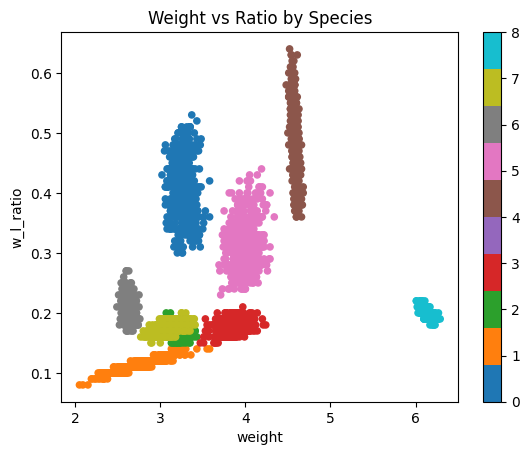

In [25]:
# Weight vs. Ratio
df.plot.scatter(
    x="weight",
    y="w_l_ratio",
    c=df["species"].astype("category").cat.codes,
    colormap="tab10",
    title="Weight vs Ratio by Species",
)
plt.show()

In [26]:
x = df[['length', 'weight', 'w_l_ratio']]

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(x)
    results.append({"k": k, "silhouette_score": silhouette_score(x, labels)})

# Convert to DataFrame
df_scores = pd.DataFrame(results)
print(df_scores.to_string(index=False))

 k  silhouette_score
 2          0.565885
 3          0.633197
 4          0.615584
 5          0.621140
 6          0.582458
 7          0.549909
 8          0.528570
 9          0.507958


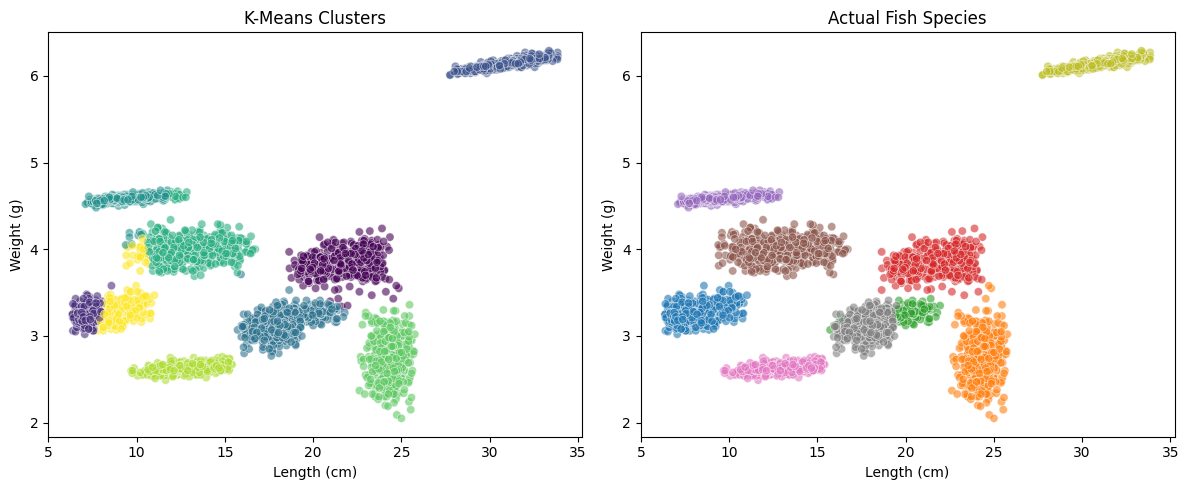

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Feature selection & scaling
X = df[['length', 'weight', 'w_l_ratio']]
X_scaled = StandardScaler().fit_transform(X)

# K-Means clustering
df['cluster'] = KMeans(n_clusters=9, init='k-means++', random_state=42).fit_predict(X_scaled)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: K-Means Clusters
sns.scatterplot(data=df, x='length', y='weight', hue='cluster', palette='viridis', alpha=0.6, ax=axes[0], legend=False)
axes[0].set(title='K-Means Clusters', xlabel='Length (cm)', ylabel='Weight (g)')

# Plot 2: Actual Fish Species
sns.scatterplot(data=df, x='length', y='weight', hue='species', alpha=0.6, ax=axes[1], legend=False)
axes[1].set(title='Actual Fish Species', xlabel='Length (cm)', ylabel='Weight (g)')

plt.tight_layout()
plt.show()

In [33]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.5657471015838218
0.6331967361469945
0.616586340280235
0.621134834727409
0.5954872062543912
0.5519119593011443
0.5311295700360986
0.5162769626330354


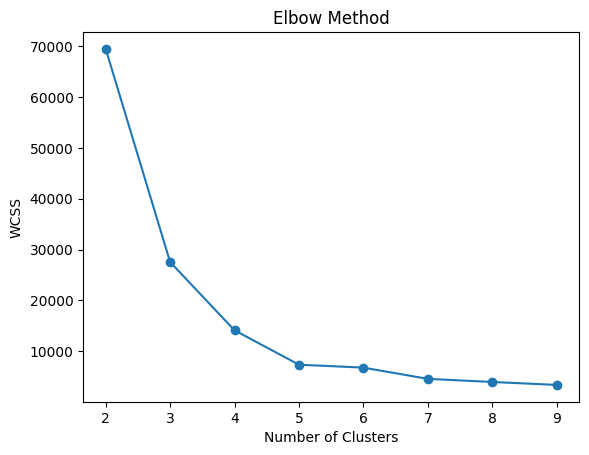

In [34]:
plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [35]:
from yellowbrick.cluster import KElbowVisualizer

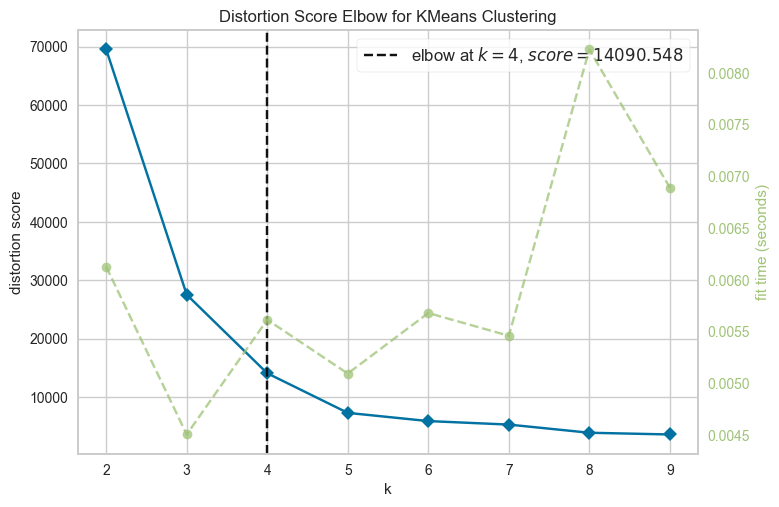

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
km=KMeans()
vis=KElbowVisualizer(km,k=(2,10))
vis.fit(x)
vis.show()

## Modeling

In [37]:
from sklearn.cluster import KMeans

In [38]:
model=KMeans(4)

In [39]:
model=model.fit(x)

In [41]:
predict=model.predict(x)

In [42]:
predict

array([2, 2, 2, ..., 1, 1, 1], shape=(4080,), dtype=int32)

In [43]:
x['cluster']=predict

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(x_scaled)

df[['length', 'weight', 'w_l_ratio', 'cluster']].head(11)

,length,weight,w_l_ratio,cluster
0,10.66,3.45,0.32,2
1,6.91,3.27,0.47,2
2,8.38,3.46,0.41,2
3,7.57,3.36,0.44,2
4,10.83,3.38,0.31,2
5,9.35,3.28,0.35,2
6,9.42,3.33,0.35,2
7,7.92,3.13,0.39,2
8,6.98,3.16,0.45,2
9,8.42,3.26,0.39,2


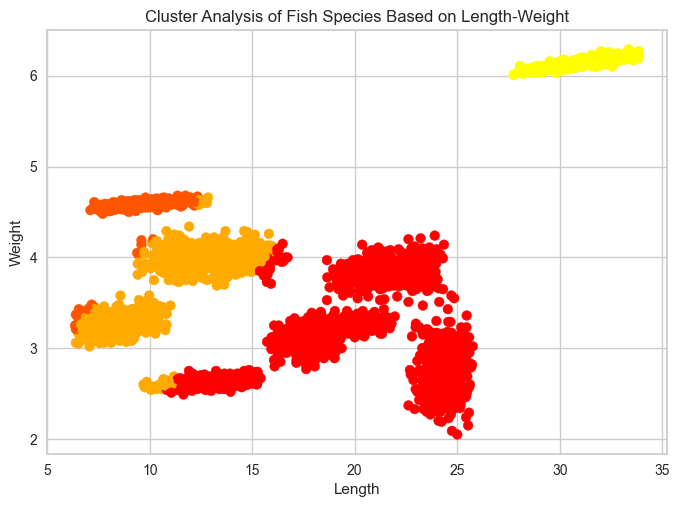

In [45]:
import matplotlib.pyplot as plt

# Scatter plot showing length vs weight, colored by cluster
plt.scatter(df['length'], df['weight'], c=df['cluster'], cmap='autumn')

# Labeling axes
plt.xlabel("Length")
plt.ylabel("Weight")

# Title
plt.title("Cluster Analysis of Fish Species Based on Length-Weight")

# Display plot
plt.show()

The Elbow Method visualizer confirmed that 4 clusters ($k = 4$) provide the optimal balance for segmenting fish species based on length, weight, and dimensional ratios. Scatter plot analysis reveals clear separation among the resulting morphological groups.